# Design & Build a RAG-Based Customer Support Assistant (with LangGraph & HITL)


In [ ]:
!pip install -qU langchain langchain-openai langchain-community langgraph chromadb pypdf sentence-transformers tiktoken reportlab

In [5]:
!pip install -qU langchain-text-splitters

2

In [2]:
import os
from google.colab import userdata

# Safely fetch the API key from Colab's hidden Secrets panel
try:
    os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')
    print("✅ API Key successfully loaded from Colab Secrets!")
except userdata.SecretNotFoundError:
    print("❌ Error: 'OPENROUTER_API_KEY' not found in Secrets.")
    print("Please click the Key icon on the left sidebar, add your API key, and enable Notebook Access.")

✅ API Key successfully loaded from Colab Secrets!


3

In [3]:
from reportlab.pdfgen import canvas

# Create a dummy PDF for our RAG system
pdf_path = "support_knowledge_base.pdf"
c = canvas.Canvas(pdf_path)
c.drawString(100, 750, "Innomatics Research Labs Customer Support Guide")
c.drawString(100, 730, "1. Password Resets: Users can reset passwords via the 'Forgot Password' link.")
c.drawString(100, 710, "2. Refund Policy: Refunds are only available within 14 days of purchase.")
c.drawString(100, 690, "3. API Rate Limits: Basic tier users get 1000 requests per day.")
c.save()
print(f"Created dummy PDF at {pdf_path}")

Created dummy PDF at support_knowledge_base.pdf


4

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

# 1. Load the PDF
loader = PyPDFLoader(pdf_path)
docs = loader.load()

# 2. Chunking Strategy [cite: 36]
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = text_splitter.split_documents(docs)

# 3. Embedding Model & Vector Store [cite: 15, 37, 38]
# Using a lightweight local embedding model so we don't need an extra API key
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_store = Chroma.from_documents(chunks, embeddings)

# 4. Retriever [cite: 39]
retriever = vector_store.as_retriever(search_kwargs={"k": 2})

print(f"Successfully embedded {len(chunks)} chunks into ChromaDB.")

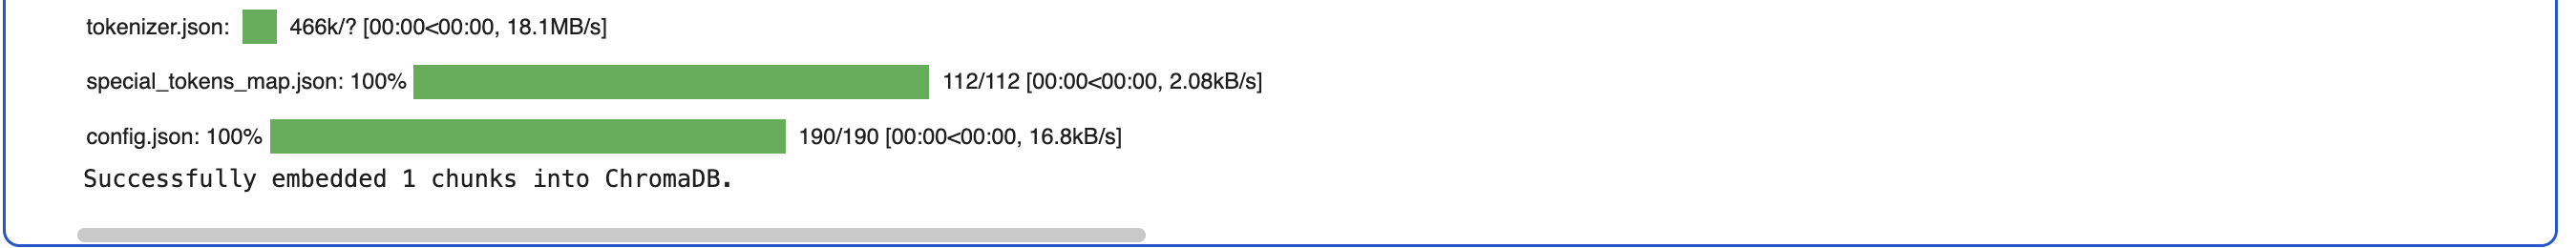

5

In [14]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# Initialize OpenRouter LLM [cite: 50]
llm = ChatOpenAI(
    openai_api_key=os.environ.get("OPENROUTER_API_KEY"),
    openai_api_base="https://openrouter.ai/api/v1",
    model_name="z-ai/glm-4.5-air:free",
    temperature=0
)

# 1. Define State Object [cite: 72, 75]
class GraphState(TypedDict):
    question: str
    context: str
    intent: str
    generation: str

# 2. Define Nodes [cite: 74]

def retrieve_and_classify(state: GraphState):
    """Retrieves context and determines if it can be answered or needs escalation."""
    question = state["question"]
    docs = retriever.invoke(question)
    context = "\n".join([d.page_content for d in docs])

    # Simple routing logic [cite: 120] based on keywords or low confidence/missing context [cite: 79]
    # (In a production app, you'd use the LLM to classify intent here)
    if not docs or "agent" in question.lower() or "human" in question.lower() or "manager" in question.lower():
        intent = "escalate"
    else:
        intent = "answer"

    return {"context": context, "intent": intent}

def generate_answer(state: GraphState):
    """Generates an answer using the retrieved context."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a helpful customer support assistant. Use the following context to answer the user's question. If you don't know, say you don't know.\n\nContext: {context}"),
        ("human", "{question}")
    ])
    chain = prompt | llm
    response = chain.invoke({"context": state["context"], "question": state["question"]})
    return {"generation": response.content}

def human_escalation(state: GraphState):
    """Dummy node. The graph will interrupt BEFORE this node for HITL."""
    # When resumed, whatever is in 'generation' (provided by the human) remains.
    return state

# 3. Conditional Routing Edge [cite: 76]
def route_query(state: GraphState):
    if state["intent"] == "escalate":
        return "human_escalation"
    return "generate_answer"

# 4. Build the Graph [cite: 41, 73]
workflow = StateGraph(GraphState)

workflow.add_node("retrieve_and_classify", retrieve_and_classify)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("human_escalation", human_escalation)

workflow.set_entry_point("retrieve_and_classify")

# Conditional routing based on intent [cite: 10, 19]
workflow.add_conditional_edges(
    "retrieve_and_classify",
    route_query,
    {
        "generate_answer": "generate_answer",
        "human_escalation": "human_escalation"
    }
)

workflow.add_edge("generate_answer", END)
workflow.add_edge("human_escalation", END)

# Compile with a checkpointer to enable pausing for HITL [cite: 11]
memory = MemorySaver()
app = workflow.compile(checkpointer=memory, interrupt_before=["human_escalation"])

print("LangGraph workflow compiled successfully.")

LangGraph workflow compiled successfully.


6

In [15]:
def run_bot(query: str, thread_id: str):
    config = {"configurable": {"thread_id": thread_id}}

    print(f"\n--- User Query: {query} ---")

    # Stream the graph execution
    for event in app.stream({"question": query}, config):
        for key, value in event.items():
            print(f"Node Executed: {key}")

    # Check if the graph paused for Human-in-the-Loop [cite: 82]
    state = app.get_state(config)
    if state.next and state.next[0] == "human_escalation":
        print("\n⚠️ [SYSTEM ALERT: ESCALATION TRIGGERED] ⚠️")
        print("Bot failed to answer or user requested human. Waiting for Human-in-the-Loop input...")

        # Simulate a human agent typing a response [cite: 84]
        human_input = input("Human Agent Response: ")

        # Update the state with the human's answer and resume the graph
        app.update_state(config, {"generation": human_input})

        # Resume graph execution
        for event in app.stream(None, config):
             pass

        final_state = app.get_state(config)
        print(f"\nFinal Output to User: {final_state.values.get('generation')}")

    else:
        # Standard answer generation [cite: 8]
        final_state = app.get_state(config)
        print(f"\nFinal Output to User:\n{final_state.values.get('generation')}")

# Test 1: Standard RAG Flow
run_bot("What is the refund policy?", thread_id="test_thread_1")

# Test 2: Escalation / HITL Flow
run_bot("I am very angry, let me talk to an agent immediately!", thread_id="test_thread_2")


--- User Query: What is the refund policy? ---
Node Executed: retrieve_and_classify
Node Executed: generate_answer

Final Output to User:
According to our refund policy, refunds are only available within 14 days of purchase. If you're requesting a refund, please make sure to do so within this timeframe from your original purchase date.

--- User Query: I am very angry, let me talk to an agent immediately! ---
Node Executed: retrieve_and_classify
Node Executed: __interrupt__

⚠️ [SYSTEM ALERT: ESCALATION TRIGGERED] ⚠️
Bot failed to answer or user requested human. Waiting for Human-in-the-Loop input...
Human Agent Response: I am so sorry for the frustration. I am a live support agent. How can I help resolve your issue today?

Final Output to User: I am so sorry for the frustration. I am a live support agent. How can I help resolve your issue today?
